<a href="https://colab.research.google.com/github/trietle/trans-keras-demo/blob/main/transformer_attention_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Essence of Attention and Transformers
### Step-by-Step Demo: Following the Transformer Data Flow
Ref: Attention Is All You Need https://arxiv.org/abs/1706.03762

```
Text --> [1. Tokenize] --> [2. Embed] --> [3. + Position] --> [4. Attention] --> [5. Multi-Head] --> [6. Encoder] --> [7. Decoder]
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

---
## Step 1: Sequence and Tokenization

A tokenizer splits text into tokens (words or subwords) and maps each one
to a unique integer ID using a vocabulary lookup table.

In [2]:
# 1a. Build a simple vocabulary

# A vocabulary is a mapping from words to integer IDs.
# Real tokenizers (like BPE or WordPiece) handle subwords

vocab = {
    '<PAD>': 0,    # padding token (used to fill short sequences)
    '<UNK>': 1,    # unknown token (for words not in vocab)
    'i'    : 2,
    'love' : 3,
    'ai'   : 4,
    'the'  : 5,
    'cat'  : 6,
    'sat'  : 7,
    'on'   : 8,
    'mat'  : 9,
}

vocab_size = len(vocab)
print(f'Vocabulary size: {vocab_size} words')
print(f'Vocabulary: {vocab}')

Vocabulary size: 10 words
Vocabulary: {'<PAD>': 0, '<UNK>': 1, 'i': 2, 'love': 3, 'ai': 4, 'the': 5, 'cat': 6, 'sat': 7, 'on': 8, 'mat': 9}


In [3]:
# 1b. Tokenize a sentence

def tokenize(sentence, vocab):
    words = sentence.lower().split()
    return [vocab.get(w, vocab['<UNK>']) for w in words]

sentence = 'the cat sat on the mat'
token_ids = tokenize(sentence, vocab)

print(f'Input sentence: "{sentence}"')
print(f'Token IDs:      {token_ids}')
print()

words = sentence.lower().split()
for word, tid in zip(words, token_ids):
    print(f'  "{word}" --> {tid}')

print()
print(f'Sequence length: {len(token_ids)}')

Input sentence: "the cat sat on the mat"
Token IDs:      [5, 6, 7, 8, 5, 9]

  "the" --> 5
  "cat" --> 6
  "sat" --> 7
  "on" --> 8
  "the" --> 5
  "mat" --> 9

Sequence length: 6


---
## Step 2: Word Embedding


```
token ID 6 ('cat') --> [0.12, -0.45, 0.78, ...]   (d_model numbers)
token ID 7 ('sat') --> [0.33,  0.21, -0.55, ...]   (d_model numbers)
```

The embedding is simply a lookup table (a matrix of shape vocab_size x d_model).
Row i of the table is the vector for token ID i.
These vectors are learned during training.

In [4]:
# 2a. Create an embedding table

d_model = 8   # embedding dimension (small for readability; paper uses 512)

# The embedding table: one row per word in the vocabulary.
# In a real model these values are learned. Here we use random initialization.
embedding_table = np.random.randn(vocab_size, d_model)

print(f'Embedding table shape: {embedding_table.shape}  (vocab_size x d_model)')
print(f'  {vocab_size} words, each represented by a {d_model}-dimensional vector.')
print()
print('Embedding table (each row is one word vector):')
print(np.round(embedding_table, 3))

Embedding table shape: (10, 8)  (vocab_size x d_model)
  10 words, each represented by a 8-dimensional vector.

Embedding table (each row is one word vector):
[[ 0.497 -0.138  0.648  1.523 -0.234 -0.234  1.579  0.767]
 [-0.469  0.543 -0.463 -0.466  0.242 -1.913 -1.725 -0.562]
 [-1.013  0.314 -0.908 -1.412  1.466 -0.226  0.068 -1.425]
 [-0.544  0.111 -1.151  0.376 -0.601 -0.292 -0.602  1.852]
 [-0.013 -1.058  0.823 -1.221  0.209 -1.96  -1.328  0.197]
 [ 0.738  0.171 -0.116 -0.301 -1.479 -0.72  -0.461  1.057]
 [ 0.344 -1.763  0.324 -0.385 -0.677  0.612  1.031  0.931]
 [-0.839 -0.309  0.331  0.976 -0.479 -0.186 -1.106 -1.196]
 [ 0.813  1.356 -0.072  1.004  0.362 -0.645  0.361  1.538]
 [-0.036  1.565 -2.62   0.822  0.087 -0.299  0.092 -1.988]]


In [5]:
# 2b. Look up embeddings for our token sequence

# Embedding is just indexing into the table: take row [token_id]
token_ids_array = np.array(token_ids)
embedded_sequence = embedding_table[token_ids_array]   # shape: (seq_len, d_model)

print(f'Token IDs:  {token_ids}')
print(f'Words:      {words}')
print(f'Embedded sequence shape: {embedded_sequence.shape}  (seq_len x d_model)')
print()

for i, (word, tid) in enumerate(zip(words, token_ids)):
    vec = np.round(embedded_sequence[i], 3)
    print(f'  "{word}" (id={tid}) --> {vec}')

Token IDs:  [5, 6, 7, 8, 5, 9]
Words:      ['the', 'cat', 'sat', 'on', 'the', 'mat']
Embedded sequence shape: (6, 8)  (seq_len x d_model)

  "the" (id=5) --> [ 0.738  0.171 -0.116 -0.301 -1.479 -0.72  -0.461  1.057]
  "cat" (id=6) --> [ 0.344 -1.763  0.324 -0.385 -0.677  0.612  1.031  0.931]
  "sat" (id=7) --> [-0.839 -0.309  0.331  0.976 -0.479 -0.186 -1.106 -1.196]
  "on" (id=8) --> [ 0.813  1.356 -0.072  1.004  0.362 -0.645  0.361  1.538]
  "the" (id=5) --> [ 0.738  0.171 -0.116 -0.301 -1.479 -0.72  -0.461  1.057]
  "mat" (id=9) --> [-0.036  1.565 -2.62   0.822  0.087 -0.299  0.092 -1.988]


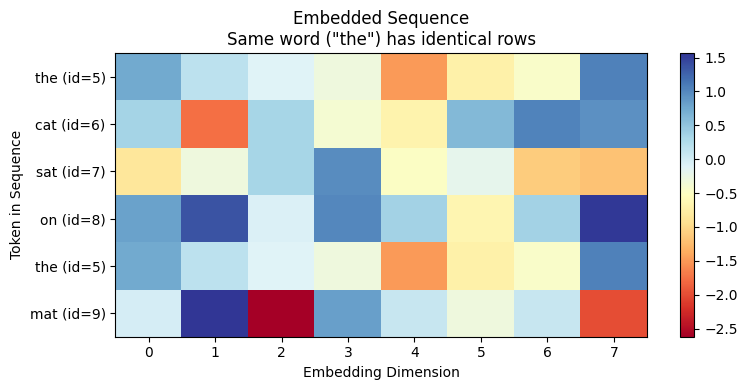

In [6]:
# 2c. Visualize: same word = same vector

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(embedded_sequence, aspect='auto', cmap='RdYlBu')

ax.set_yticks(range(len(words)))
ax.set_yticklabels([f'{w} (id={t})' for w, t in zip(words, token_ids)])
ax.set_xlabel('Embedding Dimension')
ax.set_ylabel('Token in Sequence')
ax.set_title('Embedded Sequence\n'
             'Same word ("the") has identical rows')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Step 3: Positional Encoding

Formula:
```
PE[pos, 2i]   = sin( pos / 10000^(2i / d_model) )
PE[pos, 2i+1] = cos( pos / 10000^(2i / d_model) )
```

In [7]:
# 3a. Build the Positional Encoding matrix

def positional_encoding(max_len, d_model):
    PE  = np.zeros((max_len, d_model))
    for k in range(max_len):
        # Used for mapping to column indices 0 <= i < d_model/2, with a single value of i maps to both sine and cosine functions
        for i in np.arange(int(d_model/2)):
            denominator = np.power(10000, 2*i/d_model)
            PE[k, 2*i] = np.sin(k/denominator)
            PE[k, 2*i+1] = np.cos(k/denominator)
    return PE

# 50 and 128 servs for the demo to be easy for visual
MAX_LEN = 50
D_MODEL = 128

PE = positional_encoding(MAX_LEN, D_MODEL)

print('Positional Encoding shape:', PE.shape)
print(f'  {MAX_LEN} positions, each with a unique {D_MODEL}-dimensional fingerprint.')
print()
print('First 3 positions, first 8 dimensions:')
print(np.round(PE[:3, :8], 4))

Positional Encoding shape: (50, 128)
  50 positions, each with a unique 128-dimensional fingerprint.

First 3 positions, first 8 dimensions:
[[ 0.      1.      0.      1.      0.      1.      0.      1.    ]
 [ 0.8415  0.5403  0.7617  0.6479  0.6816  0.7318  0.6047  0.7965]
 [ 0.9093 -0.4161  0.987  -0.1604  0.9975  0.0709  0.9632  0.2687]]


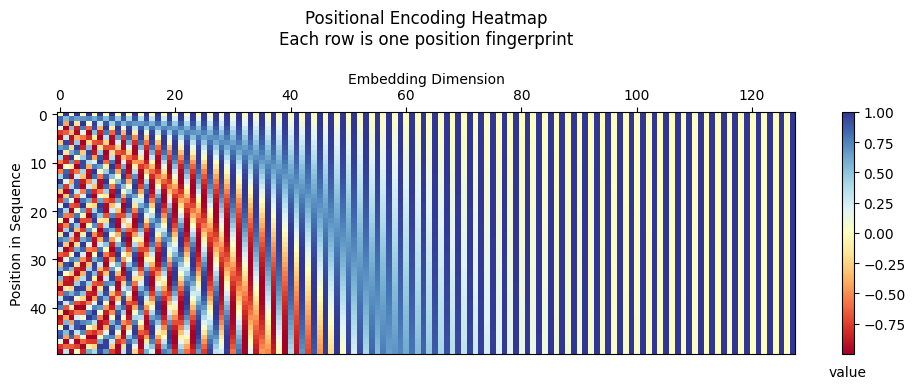

Left side (low dims): high frequency, captures fine position differences.
Right side (high dims): low frequency, captures coarse position differences.


In [8]:
# 3b. Heatmap of the full PE matrix

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(PE, aspect='auto', cmap='RdYlBu', origin='upper')

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xlabel('Embedding Dimension')

ax.set_ylabel('Position in Sequence')
ax.set_title('Positional Encoding Heatmap\nEach row is one position fingerprint', pad=20)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.set_xlabel('value', labelpad=8)
cbar.ax.xaxis.set_label_position('bottom')

plt.tight_layout()
plt.show()

print('Left side (low dims): high frequency, captures fine position differences.')
print('Right side (high dims): low frequency, captures coarse position differences.')

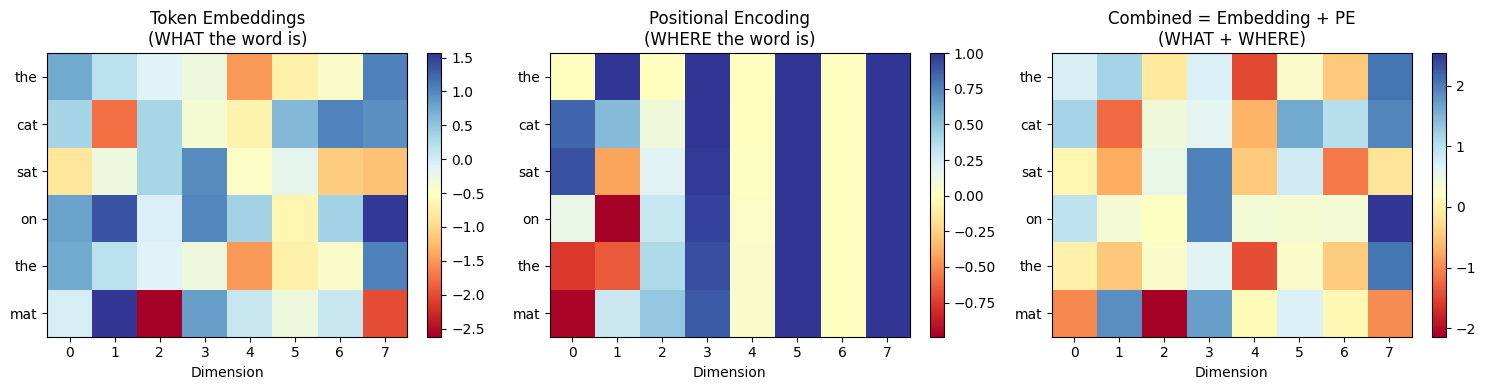

Left: same word "the" has identical rows (positions 0 and 4).
Middle: positions 0 and 4 have different PE vectors.
Right: after adding PE, the two "the" tokens are now distinguishable.


In [9]:
# 3d. Show how PE is added to embeddings

# Reuse the embedding from Step 2 (small example for readability)
sample_words = ['the', 'cat', 'sat', 'on', 'the', 'mat']
sample_seq_len = len(sample_words)

sample_embeddings = embedded_sequence
sample_pe = positional_encoding(sample_seq_len, d_model)

combined = sample_embeddings + sample_pe

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

titles = ['Token Embeddings\n(WHAT the word is)',
          'Positional Encoding\n(WHERE the word is)',
          'Combined = Embedding + PE\n(WHAT + WHERE)']
data   = [sample_embeddings, sample_pe, combined]

for ax, title, matrix in zip(axes, titles, data):
    im = ax.imshow(matrix, aspect='auto', cmap='RdYlBu')
    ax.set_yticks(range(sample_seq_len))
    ax.set_yticklabels(sample_words)
    ax.set_xlabel('Dimension')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

print('Left: same word "the" has identical rows (positions 0 and 4).')
print('Middle: positions 0 and 4 have different PE vectors.')
print('Right: after adding PE, the two "the" tokens are now distinguishable.')

---
## Step 4: Attention Mechanism (NumPy)

Now we apply attention to the embedded + positionally-encoded tokens from Steps 2-3.

In self-attention, the same input is used as Query, Key, and Value.
In practice, Q, K, V are created by passing the input through separate linear projections
(learned weight matrices). Here we simulate this with random projections.

The formula:
```
Attention(Q, K, V) = softmax( Q @ K.T / sqrt(d_k) ) @ V
```

- Q (Query) => what each token is asking for
- K (Key) => what each token offers as a label
- V (Value) => the actual content to retrieve

The dot product Q @ K.T measures similarity between every pair of tokens.
Softmax converts scores into weights that sum to 1.0 per row.
The output is a weighted blend of the value vectors.

In [10]:
# 4a. Set up Q, K, V for self-attention

# Reuse the sentence and embeddings from Steps 1-3
words = sentence.lower().split()   # ['the', 'cat', 'sat', 'on', 'the', 'mat']
seq_len = len(words)               # 6
d_k = combined.shape[1]            # 8 (same as d_model from Step 2)

# In SELF-ATTENTION, Q, K, V all come from the same input.
# In a trained model, each goes through a separate learned linear projection
# (Q = input @ W_Q, etc.). Those projections are introduced in Step 5.
# Here we use the raw input directly to focus on the attention mechanism itself.

Q = combined   # shape: (seq_len, d_k) = (6, 8)
K = combined
V = combined

print(f'Sentence: "{sentence}"')
print(f'seq_len = {seq_len}, d_k = {d_k}')
print(f'Q shape: {Q.shape}   K shape: {K.shape}   V shape: {V.shape}')
print()
print('Q = K = V = combined embeddings from Step 3 (self-attention).')

Sentence: "the cat sat on the mat"
seq_len = 6, d_k = 8
Q shape: (6, 8)   K shape: (6, 8)   V shape: (6, 8)

Q = K = V = combined embeddings from Step 3 (self-attention).


In [11]:
# 4b. Compute raw similarity scores: Q @ K.T

# scores[i, j] = how relevant token j is to token i
scores = Q @ K.T   # shape: (seq_len, seq_len) = (6, 6)

print(f'scores = Q @ K.T,  shape: {scores.shape}')
print()
print(np.round(scores, 2))
print()
print('Each cell [i,j] is the raw attention score from token i to token j.')

scores = Q @ K.T,  shape: (6, 6)

[[ 9.13  4.76  1.52  7.05  6.47  0.78]
 [ 4.76 11.29  2.49  7.56  5.97 -4.08]
 [ 1.52  2.49  6.77  2.96  2.69  1.37]
 [ 7.05  7.56  2.96 11.78  5.67  0.41]
 [ 6.47  5.97  2.69  5.67  7.28 -2.48]
 [ 0.78 -4.08  1.37  0.41 -2.48 13.37]]

Each cell [i,j] is the raw attention score from token i to token j.


In [12]:
# 4c. Scale by sqrt(d_k)

# Without scaling, large d_k causes dot products to grow large.
# Softmax on large values produces near one-hot output, killing gradients.
# Dividing by sqrt(d_k) keeps variance close to 1.

scaled_scores = scores / np.sqrt(d_k)

print(f'Scale factor: 1 / sqrt({d_k}) = {1/np.sqrt(d_k):.4f}')
print()
print('Scaled scores:')
print(np.round(scaled_scores, 3))

Scale factor: 1 / sqrt(8) = 0.3536

Scaled scores:
[[ 3.227  1.681  0.537  2.493  2.288  0.277]
 [ 1.681  3.991  0.879  2.673  2.112 -1.443]
 [ 0.537  0.879  2.393  1.046  0.953  0.485]
 [ 2.493  2.673  1.046  4.166  2.005  0.145]
 [ 2.288  2.112  0.953  2.005  2.574 -0.878]
 [ 0.277 -1.443  0.485  0.145 -0.878  4.726]]


In [13]:
# 4d. Apply Softmax row-wise

def softmax(x):
    # Subtract row max before exp for numerical stability
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

attention_weights = softmax(scaled_scores)   # shape: (6, 6)

# Note: some values appear very small because with random (untrained)
# embeddings, certain tokens happen to be much more similar than others.
# Softmax amplifies these differences. In a trained model, learned
# projections (W_Q, W_K, W_V) distribute attention more meaningfully.
print("Attention weights (after softmax):")
print(np.round(attention_weights, 4))
print()
print("Row sums (must all equal 1.0):")
print(np.round(attention_weights.sum(axis=-1), 6))

Attention weights (after softmax):
[[0.4538 0.0967 0.0308 0.2177 0.1773 0.0237]
 [0.0633 0.6376 0.0284 0.1706 0.0974 0.0028]
 [0.0773 0.1089 0.4946 0.1286 0.1172 0.0734]
 [0.118  0.1413 0.0278 0.6292 0.0725 0.0113]
 [0.2364 0.1983 0.0622 0.1783 0.3148 0.01  ]
 [0.0112 0.002  0.0138 0.0098 0.0035 0.9596]]

Row sums (must all equal 1.0):
[1. 1. 1. 1. 1. 1.]


In [14]:
# 4e. Weighted sum: attention_weights @ V

output = attention_weights @ V   # shape: (seq_len, d_k) = (6, 8)
print("Weighted sum:")
print(np.round(output, 4))

Weighted sum:
[[ 0.6325  0.429   0.0512  1.013  -0.9161  0.4513 -0.1426  2.0079]
 [ 0.9624 -0.7053  0.3368  0.8879 -0.6047  1.158   0.6154  1.9865]
 [ 0.2683 -0.275   0.203   1.537  -0.5222  0.7295 -0.469   0.7673]
 [ 0.844   0.1616  0.1973  1.5195 -0.1378  0.5345  0.258   2.245 ]
 [ 0.5683 -0.0788  0.1944  0.9692 -0.892   0.5946 -0.0508  1.9473]
 [-0.9336  1.7762 -2.0438  1.6883  0.106   0.6936  0.0765 -0.8913]]


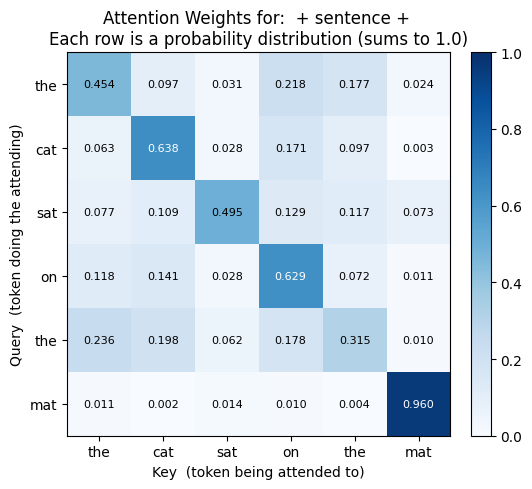

In [15]:
# 4f. Visualize attention weights

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attention_weights, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(seq_len))
ax.set_xticklabels(words)
ax.set_yticks(range(seq_len))
ax.set_yticklabels(words)
ax.set_xlabel("Key  (token being attended to)")
ax.set_ylabel("Query  (token doing the attending)")
ax.set_title("Attention Weights for: "" + sentence + ""\n"
             "Each row is a probability distribution (sums to 1.0)")

for i in range(seq_len):
    for j in range(seq_len):
        val = attention_weights[i, j]
        text_color = "white" if val > 0.5 else "black"
        # Show 3 decimals so small values are visible
        ax.text(j, i, f"{val:.3f}",
                ha="center", va="center", fontsize=8, color=text_color)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

---
## Step 5: Multi-Head Attention (Keras)

In Step 4 we used a single attention computation.
The problem: one attention can only capture one type of relationship at a time.

Multi-Head Attention runs h separate attentions in parallel,
each with its own learned projections (W_Q, W_K, W_V).
Each head can learn a different relationship (e.g., one head for syntax,
another for coreference, another for position).

```
MultiHead(Q, K, V) = Concat(head_1, ..., head_h) @ W_O
head_i             = Attention(Q @ W_Qi,  K @ W_Ki,  V @ W_Vi)
```

Tensor shape journey:
```
(batch, seq, d_model)           => input
  -> linear projections
(batch, seq, d_model)
  -> split into h heads
(batch, h, seq, d_k)            => d_k = d_model / h
  -> scaled dot-product attention per head
(batch, h, seq, d_k)
  -> concat heads + final projection
(batch, seq, d_model)           => same shape as input
```

In [16]:
# 5a. Scaled Dot-Product Attention as a Keras layer
# This is the Keras version of what we built in Step 4 with NumPy.
class ScaledDotProductAttention(layers.Layer):
    def call(self, Q, K, V, mask=None):
        d_k = tf.cast(tf.shape(K)[-1], tf.float32)
        scores = tf.matmul(Q, K, transpose_b=True)
        scaled = scores / tf.math.sqrt(d_k)

        if mask is not None:
            scaled += mask * -1e9

        weights = tf.nn.softmax(scaled, axis=-1)
        output  = tf.matmul(weights, V)
        return output, weights

In [17]:
# 5b. Multi-Head Attention layer

class MultiHeadAttention(layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'

        self.d_model   = d_model
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads

        # These are the learned projections that Step 4 was missing.
        # Each head gets its own slice of these projections.
        self.W_Q = layers.Dense(d_model, use_bias=False, name='W_Q')
        self.W_K = layers.Dense(d_model, use_bias=False, name='W_K')
        self.W_V = layers.Dense(d_model, use_bias=False, name='W_V')
        self.W_O = layers.Dense(d_model, use_bias=False, name='W_O')
        self.sdpa = ScaledDotProductAttention()

    def split_into_heads(self, x, batch_size):
        # (batch, seq, d_model) -> (batch, heads, seq, d_k)
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.d_k))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, Q, K, V, mask=None):
        batch_size = tf.shape(Q)[0]

        # Project through learned weight matrices
        Q = self.W_Q(Q)
        K = self.W_K(K)
        V = self.W_V(V)

        # Split d_model dimension across heads
        Q = self.split_into_heads(Q, batch_size)
        K = self.split_into_heads(K, batch_size)
        V = self.split_into_heads(V, batch_size)

        # Attention per head
        attn_out, weights = self.sdpa(Q, K, V, mask)

        # Merge heads: (batch, heads, seq, d_k) -> (batch, seq, d_model)
        attn_out = tf.transpose(attn_out, perm=[0, 2, 1, 3])
        attn_out = tf.reshape(attn_out, (batch_size, -1, self.d_model))

        # Final linear projection
        output = self.W_O(attn_out)
        return output, weights

In [18]:
# 5c. Run multi-head attention and trace tensor shapes

D_MODEL = 64    # embedding dimension (paper uses 512, small here for speed)
H = 4           # number of heads (paper uses 8)
SEQ_LEN = 6     # same as our sentence length
BATCH = 1       # single example

# Simulated input: one sentence of 6 tokens, each a 64-dim vector
x = tf.random.normal((BATCH, SEQ_LEN, D_MODEL))

mha = MultiHeadAttention(D_MODEL, H)
out, attn_weights = mha(x, x, x)   # self-attention: Q = K = V

print(f'Config: d_model={D_MODEL}, num_heads={H}, d_k={D_MODEL//H}')
print()
print('Shape journey:')
print(f'  Input:             {x.shape}         (batch, seq, d_model)')
print(f'  After split heads: ({BATCH}, {H}, {SEQ_LEN}, {D_MODEL//H})    (batch, heads, seq, d_k)')
print(f'  After attention:   ({BATCH}, {H}, {SEQ_LEN}, {D_MODEL//H})    (batch, heads, seq, d_k)')
print(f'  After concat:      ({BATCH}, {SEQ_LEN}, {D_MODEL})       (batch, seq, d_model)')
print(f'  Output:            {out.shape}         (batch, seq, d_model) -- same as input!')
print(f'  Weights:           {attn_weights.shape}  (batch, heads, seq, seq)')

Config: d_model=64, num_heads=4, d_k=16

Shape journey:
  Input:             (1, 6, 64)         (batch, seq, d_model)
  After split heads: (1, 4, 6, 16)    (batch, heads, seq, d_k)
  After attention:   (1, 4, 6, 16)    (batch, heads, seq, d_k)
  After concat:      (1, 6, 64)       (batch, seq, d_model)
  Output:            (1, 6, 64)         (batch, seq, d_model) -- same as input!
  Weights:           (1, 4, 6, 6)  (batch, heads, seq, seq)


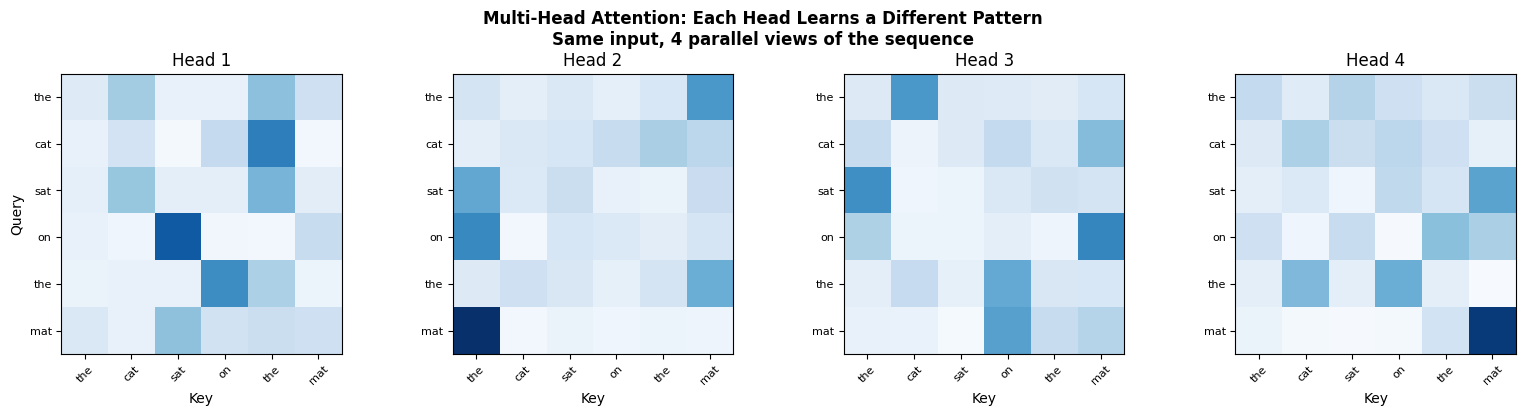

Each head has its own W_Q, W_K, W_V projections.
So each head "sees" the sequence differently.
The outputs from all 4 heads are concatenated and projected by W_O.


In [19]:
# 5d. Visualize: each head learns a different attention pattern

w = attn_weights[0].numpy()   # shape: (heads, seq, seq) -- first sample
labels = words if len(words) == SEQ_LEN else [f't{i}' for i in range(SEQ_LEN)]

fig, axes = plt.subplots(1, H, figsize=(4 * H, 4))
if H == 1:
    axes = [axes]

for h_idx, ax in enumerate(axes):
    im = ax.imshow(w[h_idx], cmap='Blues', vmin=0, vmax=w.max())
    ax.set_xticks(range(SEQ_LEN))
    ax.set_xticklabels(labels, fontsize=8, rotation=45)
    ax.set_yticks(range(SEQ_LEN))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(f'Head {h_idx + 1}')
    if h_idx == 0:
        ax.set_ylabel('Query')
    ax.set_xlabel('Key')

fig.suptitle('Multi-Head Attention: Each Head Learns a Different Pattern\n'
             f'Same input, {H} parallel views of the sequence',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Each head has its own W_Q, W_K, W_V projections.')
print(f'So each head "sees" the sequence differently.')
print(f'The outputs from all {H} heads are concatenated and projected by W_O.')

---
## Step 6: Transformer Encoder (Keras)

The Encoder Layer combines everything from Steps 3-5 into one block.
It has two sub-layers, each with a skip connection and layer normalization:

```
Input (batch, seq, d_model)
  |                                                         
  +---> Multi-Head Self-Attention ---> Dropout --+           
  |                                             |           
  +---------------------------------------------+--> Add & LayerNorm  (skip connection 1)
                                                      |               
  +---> Feed-Forward Network -------> Dropout --+     |               
  |                                             |     |               
  +---------------------------------------------+--> Add & LayerNorm  (skip connection 2)
                                                      |
                                                   Output (batch, seq, d_model)
```

Key concepts:
- Skip connection: out = LayerNorm(x + sublayer(x)). Adds input directly to output,
  creating a gradient highway that prevents vanishing gradients in deep networks.
- FFN: two dense layers with ReLU. FFN(x) = ReLU(x @ W1 + b1) @ W2 + b2.
  Typically d_ff = 4 * d_model.
- A full encoder stacks N identical layers (paper uses N=6).

In [20]:
# 6a. Feed-Forward Network

class FeedForwardNetwork(layers.Layer):
    def __init__(self, d_model, d_ff, **kwargs):
        super().__init__(**kwargs)
        # Linear e.g y = wx + b
        self.dense1 = layers.Dense(d_ff,    activation='relu', name='FFN_expand')
        self.dense2 = layers.Dense(d_model,                    name='FFN_project')

    def call(self, x):
        # Expand to d_ff dimensions, then project back to d_model
        return self.dense2(self.dense1(x))

In [21]:
# 6b. Encoder Layer

class EncoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha     = MultiHeadAttention(d_model, num_heads)
        self.ffn     = FeedForwardNetwork(d_model, d_ff)
        self.norm1   = layers.LayerNormalization(epsilon=1e-6)
        self.norm2   = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, x, training=False, mask=None):
        # Sub-layer 1: Multi-Head Self-Attention + skip connection
        attn_out, attn_weights = self.mha(x, x, x, mask)
        attn_out = self.dropout1(attn_out, training=training)
        out1 = self.norm1(x + attn_out)   # skip connection: add input back

        # Sub-layer 2: Feed-Forward Network + skip connection
        ffn_out = self.ffn(out1)
        ffn_out = self.dropout2(ffn_out, training=training)
        out2 = self.norm2(out1 + ffn_out) # skip connection: add out1 back

        return out2, attn_weights

In [22]:
# 6c. Full Transformer Encoder (N layers + embedding + PE)

class TransformerEncoder(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, d_ff,
                 vocab_size, max_seq_len, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model   = d_model
        self.embedding = layers.Embedding(vocab_size, d_model)

        # Positional encoding (same formula from Step 3, as a constant)
        self.pos_enc = positional_encoding(max_seq_len, d_model).astype(np.float32)

        self.enc_layers = [
            EncoderLayer(d_model, num_heads, d_ff, dropout_rate, name=f'enc_layer_{i}')
            for i in range(num_layers)
        ]
        self.dropout = layers.Dropout(dropout_rate)

    def call(self, token_ids, training=False, mask=None):
        seq_len = tf.shape(token_ids)[1]

        # Step 2: Embedding
        x = self.embedding(token_ids)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))  # scale as in paper

        # Step 3: Add positional encoding
        x += self.pos_enc[:seq_len, :]
        x = self.dropout(x, training=training)

        # Pass through N encoder layers
        all_weights = []
        for enc_layer in self.enc_layers:
            x, w = enc_layer(x, training=training, mask=mask)
            all_weights.append(w)

        return x, all_weights

print('TransformerEncoder model defined.')
print('It combines: Embedding + PE + N x EncoderLayer.')

TransformerEncoder model defined.
It combines: Embedding + PE + N x EncoderLayer.


In [23]:
# 6d. Build and run the encoder, trace tensor shapes

# Parameters (scaled down for demo; paper uses d_model=512, heads=8, N=6)
NUM_LAYERS = 2
D_MODEL    = 64
NUM_HEADS  = 4
D_FF       = 256    # = 4 * d_model
VOCAB_SIZE = len(vocab)  # from Step 1
MAX_SEQ    = 50

encoder = TransformerEncoder(
    num_layers=NUM_LAYERS, d_model=D_MODEL, num_heads=NUM_HEADS,
    d_ff=D_FF, vocab_size=VOCAB_SIZE, max_seq_len=MAX_SEQ
)

# Use our tokenized sentence from Step 1
input_ids = tf.constant([token_ids])  # add batch dimension: (1, 6)

enc_output, enc_weights = encoder(input_ids, training=False)

print(f'Encoder config: {NUM_LAYERS} layers, d_model={D_MODEL}, heads={NUM_HEADS}, d_ff={D_FF}')
print()
print(f'Input token IDs:  {input_ids.shape}  (batch, seq_len)')
print(f'Encoder output:   {enc_output.shape}  (batch, seq_len, d_model)')
print(f'Attention weights: {len(enc_weights)} layers, each {enc_weights[0].shape}')
print()
print('Input shape (batch, seq_len) --> Output shape (batch, seq_len, d_model).')
print('Each token now has a context-aware representation of d_model dimensions.')

Encoder config: 2 layers, d_model=64, heads=4, d_ff=256

Input token IDs:  (1, 6)  (batch, seq_len)
Encoder output:   (1, 6, 64)  (batch, seq_len, d_model)
Attention weights: 2 layers, each (1, 4, 6, 6)

Input shape (batch, seq_len) --> Output shape (batch, seq_len, d_model).
Each token now has a context-aware representation of d_model dimensions.


In [24]:
# 6e. Model summary

encoder.summary()

Model: "transformer_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (1, 6, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_layer_0 (EncoderLayer)      │ ?                      │        49,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_layer_1 (EncoderLayer)      │ ?                      │        49,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,096 (391.00 KB)

 Trainable params: 100,096 (391.00 KB)

 Non-trainable params: 0 (0.00 B)

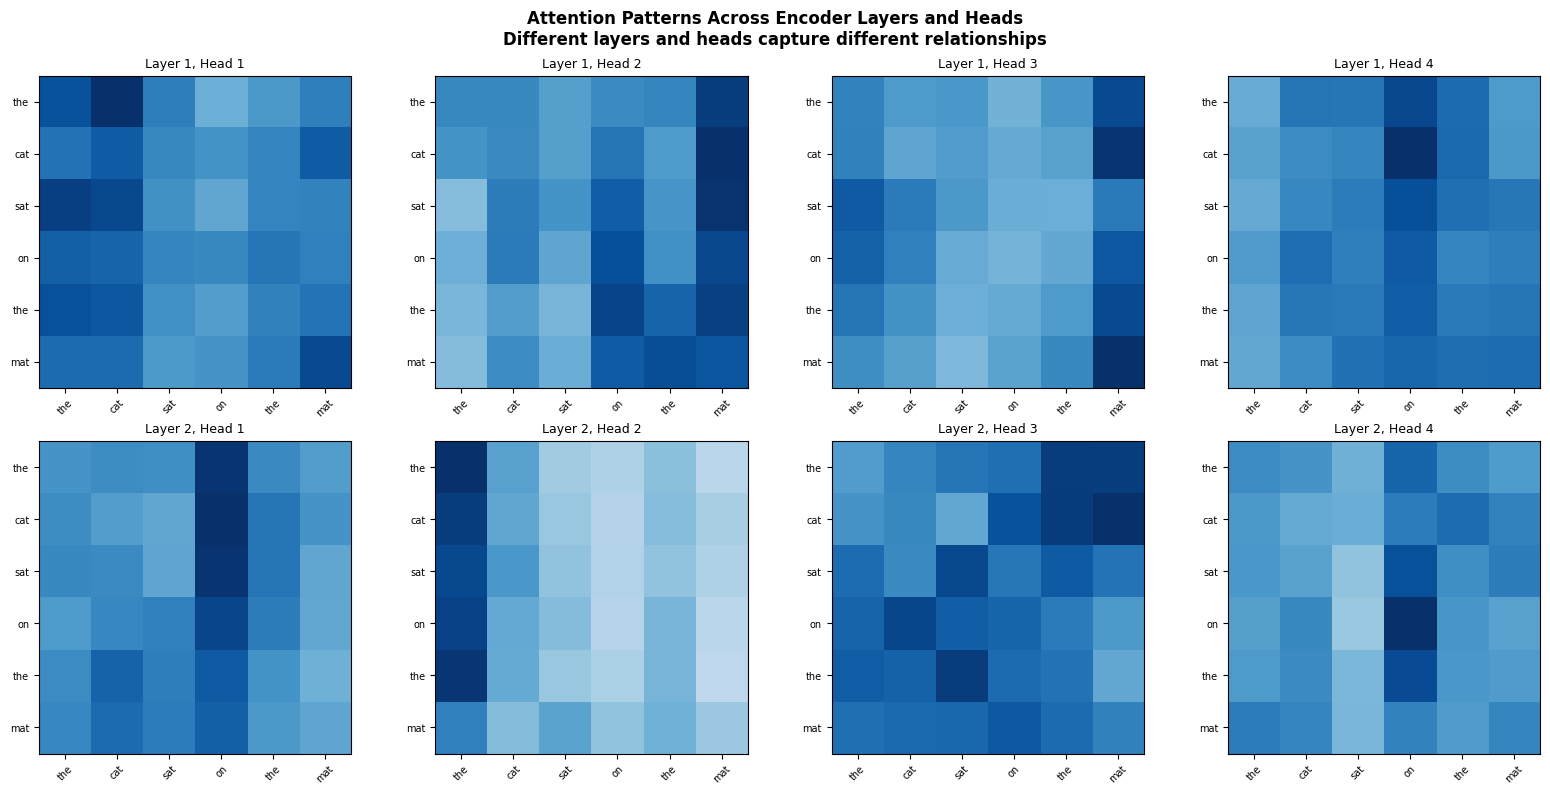

In [25]:
# 6g. Visualize attention from each encoder layer

fig, axes = plt.subplots(NUM_LAYERS, NUM_HEADS, figsize=(4 * NUM_HEADS, 4 * NUM_LAYERS))
if NUM_LAYERS == 1:
    axes = [axes]

for layer_idx in range(NUM_LAYERS):
    w = enc_weights[layer_idx][0].numpy()  # (heads, seq, seq)
    for h_idx in range(NUM_HEADS):
        ax = axes[layer_idx][h_idx]
        im = ax.imshow(w[h_idx], cmap='Blues', vmin=0)
        ax.set_xticks(range(len(words)))
        ax.set_xticklabels(words, fontsize=7, rotation=45)
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=7)
        ax.set_title(f'Layer {layer_idx+1}, Head {h_idx+1}', fontsize=9)

fig.suptitle('Attention Patterns Across Encoder Layers and Heads\n'
             'Different layers and heads capture different relationships',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## Step 7: Transformer Decoder (Keras)

The Decoder is similar to the Encoder but adds two new ideas.
We demonstrate with a translation task: English -> Vietnamese.

```
Encoder input (English):    "the cat sat on the mat"
Decoder input (Vietnamese): "con mèo ngồi trên tấm thảm"
```

**1. Masked Self-Attention (Causal Mask)**

When generating text, the decoder produces one token at a time.
At each step, it must not look at future tokens (it has not generated them yet).
A triangular mask blocks attention to future positions:
```
       con  mèo  ngồi trên tấm  thảm
con  [  1    0    0    0    0    0  ]  --> can only see itself
mèo  [  1    1    0    0    0    0  ]  --> can see con, mèo
ngồi [  1    1    1    0    0    0  ]  --> can see con, mèo, ngồi
trên [  1    1    1    1    0    0  ]  --> ...
tấm  [  1    1    1    1    1    0  ]
thảm [  1    1    1    1    1    1  ]  --> can see all past tokens
```

**2. Cross-Attention (Encoder-Decoder Attention)**

The decoder needs to read the encoder output (English). It does this with cross-attention:
- Query comes from the decoder (Vietnamese: what am I looking for?)
- Key and Value come from the encoder (English: what is available?)

This is how the decoder "reads" the source sentence while generating the translation.

**Decoder Layer structure:**
```
Target Input (Vietnamese)
  |
  v
Masked Self-Attention  -->  Add & Norm   (can only see past Vietnamese tokens)
  |
  v
Cross-Attention        -->  Add & Norm   (Q=Vietnamese, K/V=English from encoder)
  |
  v
Feed-Forward Network   -->  Add & Norm
  |
  v
Output
```

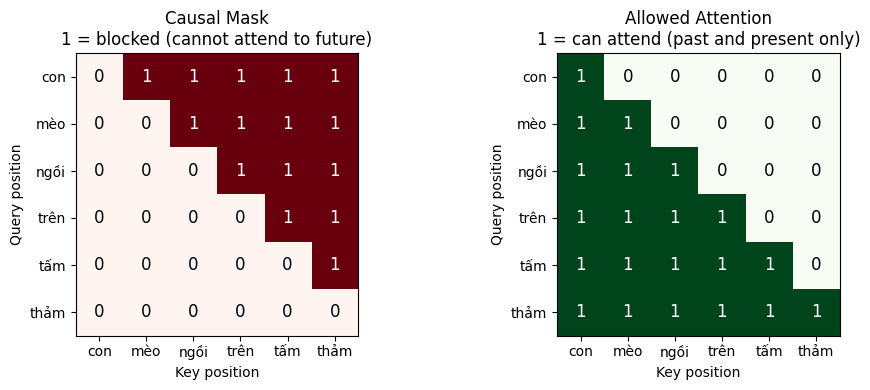

Row 0 ("con"): can only see itself.
Row 3 ("trên"): can see "con", "mèo", "ngồi", "trên" but NOT "tấm" or "thảm" ahead.


In [26]:
# 7a. Causal mask: prevent looking at future tokens

def create_causal_mask(seq_len):
    # Upper triangle = 1 (future positions to block)
    # We return a mask where 1 means "block this position"
    mask = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
    return mask[tf.newaxis, tf.newaxis, :, :]  # (1, 1, seq, seq) for broadcasting

# Vietnamese target sentence
vn_words = ['con', 'mèo', 'ngồi', 'trên', 'tấm', 'thảm']

sample_mask = create_causal_mask(6)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: the raw mask (1 = blocked)
ax = axes[0]
mask_display = sample_mask[0, 0].numpy()
im = ax.imshow(mask_display, cmap='Reds', vmin=0, vmax=1)
for i in range(6):
    for j in range(6):
        val = int(mask_display[i, j])
        ax.text(j, i, str(val), ha='center', va='center', fontsize=12,
                color='white' if val else 'black')
ax.set_xticks(range(6)); ax.set_xticklabels(vn_words)
ax.set_yticks(range(6)); ax.set_yticklabels(vn_words)
ax.set_title('Causal Mask\n1 = blocked (cannot attend to future)')
ax.set_xlabel('Key position')
ax.set_ylabel('Query position')

# Right: what attention sees after masking
ax = axes[1]
allowed = 1 - mask_display
im = ax.imshow(allowed, cmap='Greens', vmin=0, vmax=1)
for i in range(6):
    for j in range(6):
        val = int(allowed[i, j])
        ax.text(j, i, str(val), ha='center', va='center', fontsize=12,
                color='white' if val else 'black')
ax.set_xticks(range(6)); ax.set_xticklabels(vn_words)
ax.set_yticks(range(6)); ax.set_yticklabels(vn_words)
ax.set_title('Allowed Attention\n1 = can attend (past and present only)')
ax.set_xlabel('Key position')
ax.set_ylabel('Query position')

plt.tight_layout()
plt.show()

print('Row 0 ("con"): can only see itself.')
print('Row 3 ("trên"): can see "con", "mèo", "ngồi", "trên" but NOT "tấm" or "thảm" ahead.')

In [27]:
# 7b. Decoder Layer

class DecoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        # Sub-layer 1: Masked self-attention
        self.masked_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1      = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1   = layers.Dropout(dropout_rate)

        # Sub-layer 2: Cross-attention (encoder-decoder)
        self.cross_mha  = MultiHeadAttention(d_model, num_heads)
        self.norm2      = layers.LayerNormalization(epsilon=1e-6)
        self.dropout2   = layers.Dropout(dropout_rate)

        # Sub-layer 3: Feed-forward network
        self.ffn        = FeedForwardNetwork(d_model, d_ff)
        self.norm3      = layers.LayerNormalization(epsilon=1e-6)
        self.dropout3   = layers.Dropout(dropout_rate)

    def call(self, x, enc_output, training=False, causal_mask=None):
        # Sub-layer 1: Masked self-attention (decoder attends to itself, past only)
        attn1, self_attn_weights = self.masked_mha(x, x, x, mask=causal_mask)
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.norm1(x + attn1)

        # Sub-layer 2: Cross-attention (Q from decoder, K/V from encoder)
        attn2, cross_attn_weights = self.cross_mha(out1, enc_output, enc_output)
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.norm2(out1 + attn2)

        # Sub-layer 3: Feed-forward network
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out, training=training)
        out3 = self.norm3(out2 + ffn_out)

        return out3, self_attn_weights, cross_attn_weights

print('DecoderLayer defined.')
print('3 sub-layers: Masked Self-Attention -> Cross-Attention -> FFN')
print('Each with skip connections and layer normalization.')

DecoderLayer defined.
3 sub-layers: Masked Self-Attention -> Cross-Attention -> FFN
Each with skip connections and layer normalization.


In [28]:
# 7c. Full Transformer Decoder

class TransformerDecoder(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, d_ff,
                 vocab_size, max_seq_len, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model   = d_model
        self.embedding = layers.Embedding(vocab_size, d_model)
        self.pos_enc   = positional_encoding(max_seq_len, d_model).astype(np.float32)

        self.dec_layers = [
            DecoderLayer(d_model, num_heads, d_ff, dropout_rate, name=f'dec_layer_{i}')
            for i in range(num_layers)
        ]
        self.dropout = layers.Dropout(dropout_rate)

    def call(self, token_ids, enc_output, training=False):
        seq_len = tf.shape(token_ids)[1]
        causal_mask = create_causal_mask(seq_len)

        x = self.embedding(token_ids)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_enc[:seq_len, :]
        x = self.dropout(x, training=training)

        all_self_weights  = []
        all_cross_weights = []
        for dec_layer in self.dec_layers:
            x, sw, cw = dec_layer(x, enc_output, training=training,
                                  causal_mask=causal_mask)
            all_self_weights.append(sw)
            all_cross_weights.append(cw)

        return x, all_self_weights, all_cross_weights

print('TransformerDecoder model defined.')

TransformerDecoder model defined.


In [29]:
# 7d. Run encoder + decoder together (English -> Vietnamese)

# Vietnamese vocabulary for the target sentence
vn_vocab = {
    '<PAD>': 0,
    '<UNK>': 1,
    'con'  : 2,
    'mèo'  : 3,
    'ngồi' : 4,
    'trên' : 5,
    'tấm'  : 6,
    'thảm' : 7,
}

vn_sentence = 'con mèo ngồi trên tấm thảm'
vn_token_ids = [vn_vocab[w] for w in vn_sentence.split()]

decoder = TransformerDecoder(
    num_layers=NUM_LAYERS, d_model=D_MODEL, num_heads=NUM_HEADS,
    d_ff=D_FF, vocab_size=len(vn_vocab), max_seq_len=MAX_SEQ
)

# Encoder output from Step 6d (English)
target_ids = tf.constant([vn_token_ids])   # (1, 6)

dec_output, self_weights, cross_weights = decoder(
    target_ids, enc_output, training=False
)

print('English -> Vietnamese translation data flow:')
print()
print(f'  Source (English):     "{sentence}"')
print(f'  Target (Vietnamese):  "{vn_sentence}"')
print()
print(f'  Encoder input:   {input_ids.shape}    token IDs: {token_ids}')
print(f'  Encoder output:  {enc_output.shape}  (batch, src_seq, d_model)')
print(f'  Decoder input:   {target_ids.shape}    token IDs: {vn_token_ids}')
print(f'  Decoder output:  {dec_output.shape}  (batch, tgt_seq, d_model)')
print()
print(f'  Self-attention weights:  {len(self_weights)} layers, each {self_weights[0].shape}')
print(f'  Cross-attention weights: {len(cross_weights)} layers, each {cross_weights[0].shape}')

English -> Vietnamese translation data flow:

  Source (English):     "the cat sat on the mat"
  Target (Vietnamese):  "con mèo ngồi trên tấm thảm"

  Encoder input:   (1, 6)    token IDs: [5, 6, 7, 8, 5, 9]
  Encoder output:  (1, 6, 64)  (batch, src_seq, d_model)
  Decoder input:   (1, 6)    token IDs: [2, 3, 4, 5, 6, 7]
  Decoder output:  (1, 6, 64)  (batch, tgt_seq, d_model)

  Self-attention weights:  2 layers, each (1, 4, 6, 6)
  Cross-attention weights: 2 layers, each (1, 4, 6, 6)


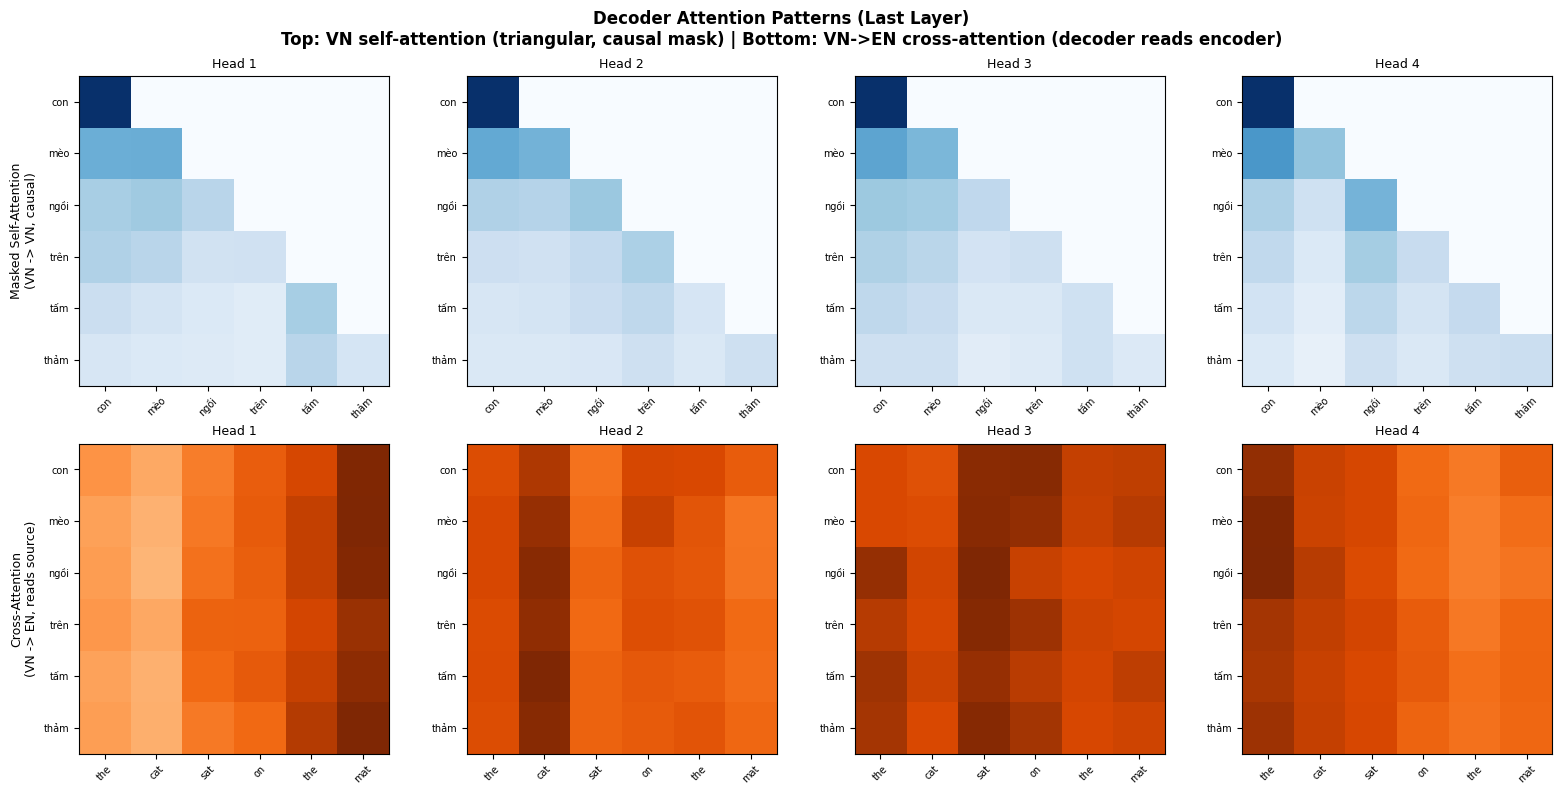

Top row (blue): masked self-attention among Vietnamese tokens.
  Notice the triangular pattern -- each VN token only sees past tokens.

Bottom row (orange): cross-attention from Vietnamese to English.
  Y-axis: Vietnamese query (meo, ngoi...), X-axis: English key (cat, sat...)
  In a trained model, "mèo" would attend strongly to "cat" (its translation).


In [30]:
# 7e. Visualize: masked self-attention vs cross-attention

fig, axes = plt.subplots(2, NUM_HEADS, figsize=(4 * NUM_HEADS, 8))

# Row 1: Masked self-attention (Vietnamese -> Vietnamese, last layer)
sw = self_weights[-1][0].numpy()    # (heads, tgt_seq, tgt_seq)
for h_idx in range(NUM_HEADS):
    ax = axes[0][h_idx]
    im = ax.imshow(sw[h_idx], cmap='Blues', vmin=0)
    ax.set_xticks(range(len(vn_words)))
    ax.set_xticklabels(vn_words, fontsize=7, rotation=45)
    ax.set_yticks(range(len(vn_words)))
    ax.set_yticklabels(vn_words, fontsize=7)
    ax.set_title(f'Head {h_idx+1}', fontsize=9)
    if h_idx == 0:
        ax.set_ylabel('Masked Self-Attention\n(VN -> VN, causal)', fontsize=9)

# Row 2: Cross-attention (Vietnamese Query -> English Key/Value, last layer)
cw = cross_weights[-1][0].numpy()   # (heads, tgt_seq, src_seq)
for h_idx in range(NUM_HEADS):
    ax = axes[1][h_idx]
    im = ax.imshow(cw[h_idx], cmap='Oranges', vmin=0)
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, fontsize=7, rotation=45)
    ax.set_yticks(range(len(vn_words)))
    ax.set_yticklabels(vn_words, fontsize=7)
    ax.set_title(f'Head {h_idx+1}', fontsize=9)
    if h_idx == 0:
        ax.set_ylabel('Cross-Attention\n(VN -> EN, reads source)', fontsize=9)

fig.suptitle('Decoder Attention Patterns (Last Layer)\n'
             'Top: VN self-attention (triangular, causal mask) | '
             'Bottom: VN->EN cross-attention (decoder reads encoder)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('Top row (blue): masked self-attention among Vietnamese tokens.')
print('  Notice the triangular pattern -- each VN token only sees past tokens.')
print()
print('Bottom row (orange): cross-attention from Vietnamese to English.')
print('  Y-axis: Vietnamese query (meo, ngoi...), X-axis: English key (cat, sat...)')
print('  In a trained model, "mèo" would attend strongly to "cat" (its translation).')

---
### Final Output Layer: Linear + Softmax

This is the last piece of the Transformer (top of the Decoder in the original paper).

The Decoder gives us a vector of d_model dimensions for each position.
But we need a **word** as output, not a vector.

Solution:
```
Decoder output (d_model)  -->  Linear (d_model -> vocab_size)  -->  Softmax  -->  Probabilities
```

The Linear layer projects d_model dimensions into vocab_size dimensions.
Softmax converts those into a probability distribution over every word in the vocabulary.
We pick the word with the highest probability (argmax).

In [31]:
# 7f. Linear + Softmax output layer

# This is the top of the Decoder in the original paper.
# It converts the decoder vector into word probabilities.

vn_vocab_list = list(vn_vocab.keys())   # ['<PAD>', '<UNK>', 'con', 'mèo', ...]
vn_vocab_size = len(vn_vocab)

# Linear projection: (batch, seq, d_model) -> (batch, seq, vocab_size)
output_projection = layers.Dense(vn_vocab_size, name='output_linear')
logits = output_projection(dec_output)   # raw scores (unnormalized)

# Softmax: convert to probabilities
probabilities = tf.nn.softmax(logits, axis=-1)   # (batch, seq, vocab_size)

print(f'Decoder output shape:   {dec_output.shape}    (batch, seq, d_model)')
print(f'After Linear layer:     {logits.shape}        (batch, seq, vocab_size={vn_vocab_size})')
print(f'After Softmax:          {probabilities.shape}  (batch, seq, vocab_size={vn_vocab_size})')
print()
print('Each position now has a probability distribution over the Vietnamese vocabulary.')

Decoder output shape:   (1, 6, 64)    (batch, seq, d_model)
After Linear layer:     (1, 6, 8)        (batch, seq, vocab_size=8)
After Softmax:          (1, 6, 8)  (batch, seq, vocab_size=8)

Each position now has a probability distribution over the Vietnamese vocabulary.


In [32]:
# 7g. Compare: untrained vs trained (simulated)

probs_untrained = probabilities[0].numpy()   # real (random) output
predicted_ids_untrained = tf.argmax(probabilities[0], axis=-1).numpy()

# Simulate what a trained model would produce:
# High probability (~0.90) on the correct target word,
# small noise spread across other words.
target_vn_ids = [vn_vocab[w] for w in vn_words]

probs_trained = np.full((len(vn_words), vn_vocab_size), 0.02)  # base noise
for pos in range(len(vn_words)):
    correct_id = target_vn_ids[pos]
    probs_trained[pos, correct_id] = 0.90    # high confidence
    # normalize so each row sums to 1
    probs_trained[pos] /= probs_trained[pos].sum()

predicted_ids_trained = np.argmax(probs_trained, axis=-1)

print('=== UNTRAINED MODEL (random weights) ===')
print(f'{"Pos":<5} {"Target":<8} {"Predicted":<10} {"Conf":<8}')
print('-' * 35)
for pos in range(len(vn_words)):
    pred_id = predicted_ids_untrained[pos]
    print(f'{pos:<5} {vn_words[pos]:<8} {vn_vocab_list[pred_id]:<10} {probs_untrained[pos, pred_id]:.3f}')

print()
print('=== TRAINED MODEL (simulated) ===')
print(f'{"Pos":<5} {"Target":<8} {"Predicted":<10} {"Conf":<8}')
print('-' * 35)
for pos in range(len(vn_words)):
    pred_id = predicted_ids_trained[pos]
    print(f'{pos:<5} {vn_words[pos]:<8} {vn_vocab_list[pred_id]:<10} {probs_trained[pos, pred_id]:.3f}')

print()
print('After training, predictions match targets with ~90% confidence.')

=== UNTRAINED MODEL (random weights) ===
Pos   Target   Predicted  Conf    
-----------------------------------
0     con      <UNK>      0.419
1     mèo      <UNK>      0.404
2     ngồi     <UNK>      0.426
3     trên     <UNK>      0.381
4     tấm      <UNK>      0.413
5     thảm     <UNK>      0.445

=== TRAINED MODEL (simulated) ===
Pos   Target   Predicted  Conf    
-----------------------------------
0     con      con        0.865
1     mèo      mèo        0.865
2     ngồi     ngồi       0.865
3     trên     trên       0.865
4     tấm      tấm        0.865
5     thảm     thảm       0.865

After training, predictions match targets with ~90% confidence.


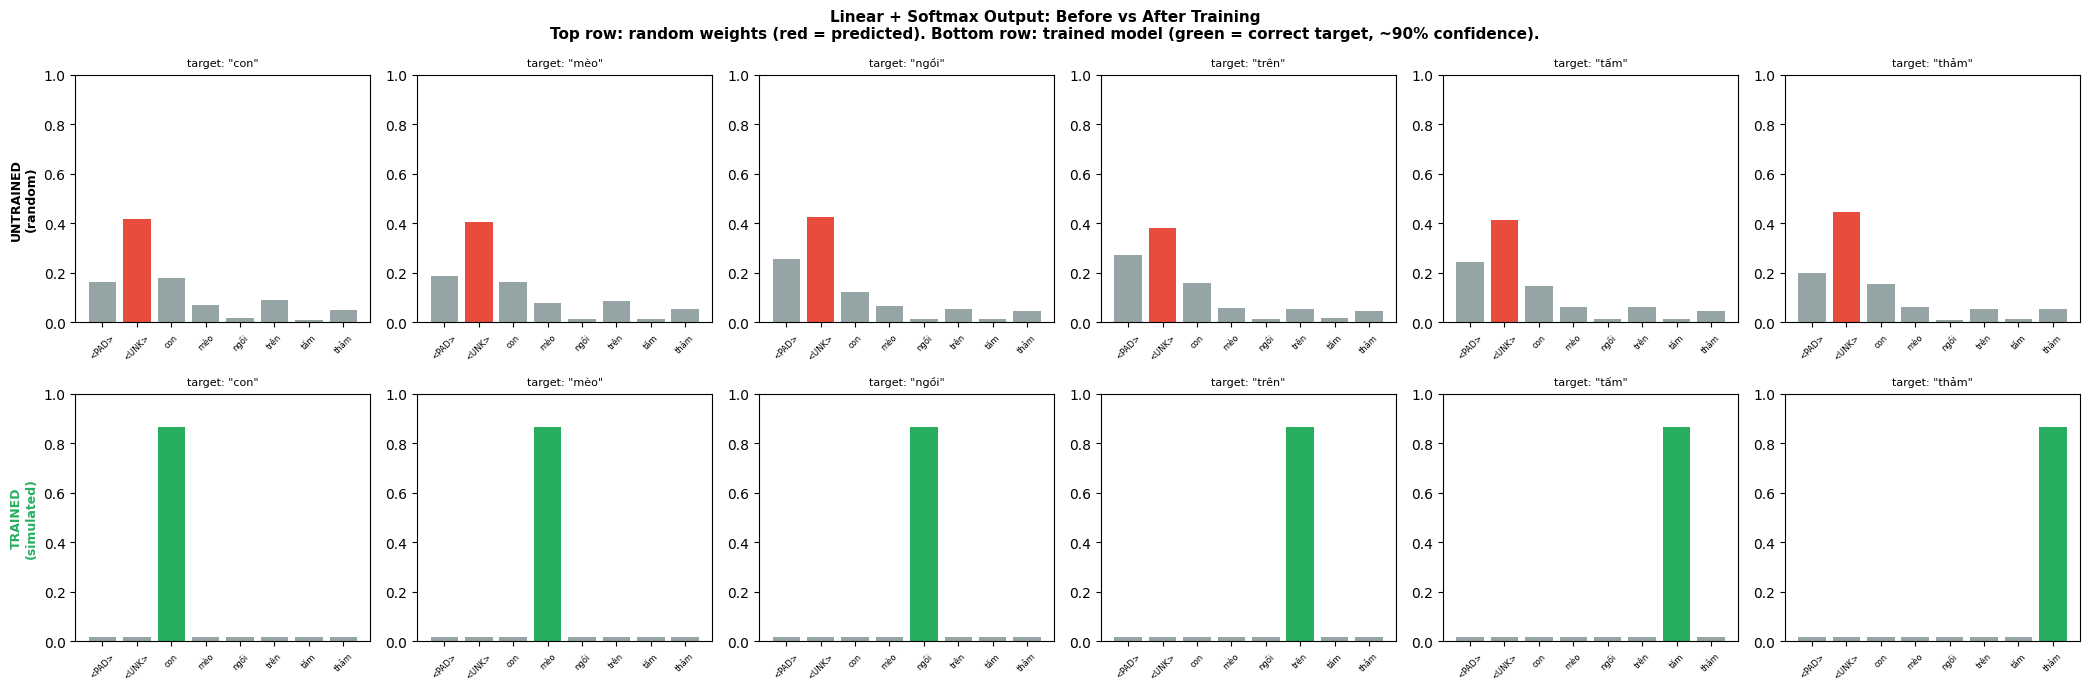

Top: untrained model predicts random words -- useless.
Bottom: trained model puts ~90% probability on the correct Vietnamese word.

This is the ENTIRE Transformer pipeline:
  "the cat sat on the mat" --> Encoder --> Decoder --> Linear + Softmax
  --> "con mèo ngồi trên tấm thảm"


In [33]:
# 7h. Visualize: untrained vs trained (simulated)

fig, axes = plt.subplots(2, len(vn_words), figsize=(3.5 * len(vn_words), 7))

for pos in range(len(vn_words)):
    # Top row: UNTRAINED (random)
    ax = axes[0][pos]
    p = probs_untrained[pos]
    colors = ['#e74c3c' if i == predicted_ids_untrained[pos] else '#95a5a6'
              for i in range(vn_vocab_size)]
    ax.bar(range(vn_vocab_size), p, color=colors)
    ax.set_xticks(range(vn_vocab_size))
    ax.set_xticklabels(vn_vocab_list, rotation=45, fontsize=6)
    ax.set_ylim(0, 1)
    ax.set_title(f'target: "{vn_words[pos]}"', fontsize=8)
    if pos == 0:
        ax.set_ylabel('UNTRAINED\n(random)', fontsize=9, fontweight='bold')

    # Bottom row: TRAINED (simulated)
    ax = axes[1][pos]
    p = probs_trained[pos]
    colors = ['#27ae60' if i == target_vn_ids[pos] else '#95a5a6'
              for i in range(vn_vocab_size)]
    ax.bar(range(vn_vocab_size), p, color=colors)
    ax.set_xticks(range(vn_vocab_size))
    ax.set_xticklabels(vn_vocab_list, rotation=45, fontsize=6)
    ax.set_ylim(0, 1)
    ax.set_title(f'target: "{vn_words[pos]}"', fontsize=8)
    if pos == 0:
        ax.set_ylabel('TRAINED\n(simulated)', fontsize=9, fontweight='bold', color='#27ae60')

fig.suptitle('Linear + Softmax Output: Before vs After Training\n'
             'Top row: random weights (red = predicted). '
             'Bottom row: trained model (green = correct target, ~90% confidence).',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

print('Top: untrained model predicts random words -- useless.')
print('Bottom: trained model puts ~90% probability on the correct Vietnamese word.')
print()
print('This is the ENTIRE Transformer pipeline:')
print('  "the cat sat on the mat" --> Encoder --> Decoder --> Linear + Softmax')
print('  --> "con mèo ngồi trên tấm thảm"')

---
## Step 8: Training the Transformer

Now let's actually **train** our Transformer to translate!

We will:
1. Wrap Encoder + Decoder + Output Layer into one model
2. Prepare training data with **teacher forcing**
3. Run gradient descent and watch the loss decrease
4. See predictions improve from random to correct

**Teacher Forcing:** during training, the decoder receives the correct
previous tokens as input (shifted right), not its own predictions.

```
Decoder input:  [<PAD>  con   mèo   ngồi  trên  tấm ]  (shifted right)
Labels:         [con    mèo   ngồi  trên  tấm   tham]  (predict these)
```

We use `<PAD>` (id=0) as the start-of-sequence token for simplicity.

In [34]:
# 8a. Complete Transformer model

class Transformer(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, max_seq_len,
                 dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.encoder = TransformerEncoder(
            num_layers, d_model, num_heads, d_ff,
            src_vocab_size, max_seq_len, dropout_rate)
        self.decoder = TransformerDecoder(
            num_layers, d_model, num_heads, d_ff,
            tgt_vocab_size, max_seq_len, dropout_rate)
        self.final_layer = layers.Dense(tgt_vocab_size,
                                       name='output_projection')

    def call(self, src_ids, tgt_ids, training=False):
        enc_output, _ = self.encoder(src_ids, training=training)
        dec_output, _, _ = self.decoder(tgt_ids, enc_output,
                                       training=training)
        logits = self.final_layer(dec_output)
        return logits

print('Transformer model class defined.')
print('It wraps: Encoder + Decoder + Output Dense layer.')

Transformer model class defined.
It wraps: Encoder + Decoder + Output Dense layer.


In [35]:
# 8b. Prepare training data (teacher forcing)

# Source: English sentence
src_train = tf.constant([token_ids])   # [5, 6, 7, 8, 5, 9]

# Target input: shifted right (start with <PAD> as start token)
tgt_train_input = tf.constant([[0] + vn_token_ids[:-1]])  # [0, 2, 3, 4, 5, 6]

# Labels: what the model should predict at each position
tgt_train_labels = tf.constant([vn_token_ids])   # [2, 3, 4, 5, 6, 7]

vn_vocab_list = list(vn_vocab.keys())
print('Teacher forcing setup:')
print(f'  Encoder input:  {[list(vocab.keys())[i] for i in src_train[0].numpy()]}')
print(f'  Decoder input:  {[vn_vocab_list[i] for i in tgt_train_input[0].numpy()]}  (shifted right)')
print(f'  Labels:         {[vn_vocab_list[i] for i in tgt_train_labels[0].numpy()]}  (predict these)')

# Build model
model = Transformer(
    num_layers=NUM_LAYERS, d_model=D_MODEL,
    num_heads=NUM_HEADS, d_ff=D_FF,
    src_vocab_size=len(vocab),
    tgt_vocab_size=len(vn_vocab),
    max_seq_len=MAX_SEQ,
)

# Build weights by running one forward pass
_ = model(src_train, tgt_train_input, training=False)

num_params = sum(p.numpy().size for p in model.trainable_variables)
print(f'\nModel built! Trainable parameters: {num_params:,}')

Teacher forcing setup:
  Encoder input:  ['the', 'cat', 'sat', 'on', 'the', 'mat']
  Decoder input:  ['<PAD>', 'con', 'mèo', 'ngồi', 'trên', 'tấm']  (shifted right)
  Labels:         ['con', 'mèo', 'ngồi', 'trên', 'tấm', 'thảm']  (predict these)

Model built! Trainable parameters: 233,608


In [36]:
# 8c. Training loop

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

losses = []
EPOCHS = 300

print(f'Training for {EPOCHS} epochs...\n')

for epoch in range(EPOCHS):
    with tf.GradientTape() as tape:
        logits = model(src_train, tgt_train_input, training=True)
        loss = loss_fn(tgt_train_labels, logits)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    losses.append(float(loss))

    if epoch % 50 == 0 or epoch == EPOCHS - 1:
        print(f'  Epoch {epoch:3d}/{EPOCHS}  loss = {float(loss):.4f}')

print(model.summary())
print('\nTraining complete!')

Training for 300 epochs...

  Epoch   0/300  loss = 2.2602
  Epoch  50/300  loss = 0.0082
  Epoch 100/300  loss = 0.0018
  Epoch 150/300  loss = 0.0014
  Epoch 200/300  loss = 0.0021
  Epoch 250/300  loss = 0.0007
  Epoch 299/300  loss = 0.0007


Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ transformer_encoder_1           │ ?                      │       100,096 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder_1           │ ?                      │       132,992 │
│ (TransformerDecoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_projection (Dense)       │ (1, 6, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,608 (912.53 KB)

 Trainable params: 233,608 (912.53 KB)

 Non-trainable params: 0 (0.00 B)

None

Training complete!


In [37]:
# 8d. Predictions after training

logits = model(src_train, tgt_train_input, training=False)
probs = tf.nn.softmax(logits, axis=-1)
predicted_ids = tf.argmax(probs[0], axis=-1).numpy()
label_ids = tgt_train_labels[0].numpy()

print('=== PREDICTIONS AFTER TRAINING ===\n')
print(f'{"Pos":<5} {"Target":<8} {"Predicted":<10} {"Conf":<8} Match')
print('-' * 42)
all_correct = True
for pos in range(len(label_ids)):
    target_word = vn_vocab_list[label_ids[pos]]
    pred_word = vn_vocab_list[predicted_ids[pos]]
    conf = float(probs[0][pos][predicted_ids[pos]])
    match = '\u2713' if pred_word == target_word else '\u2717'
    if pred_word != target_word:
        all_correct = False
    print(f'{pos:<5} {target_word:<8} {pred_word:<10} {conf:.3f}    {match}')

print()
if all_correct:
    print('All predictions correct! The model learned the translation.')
else:
    print('Some predictions wrong. Try more epochs or adjust learning rate.')

=== PREDICTIONS AFTER TRAINING ===

Pos   Target   Predicted  Conf     Match
------------------------------------------
0     con      con        1.000    ✓
1     mèo      mèo        1.000    ✓
2     ngồi     ngồi       1.000    ✓
3     trên     trên       1.000    ✓
4     tấm      tấm        1.000    ✓
5     thảm     thảm       1.000    ✓

All predictions correct! The model learned the translation.


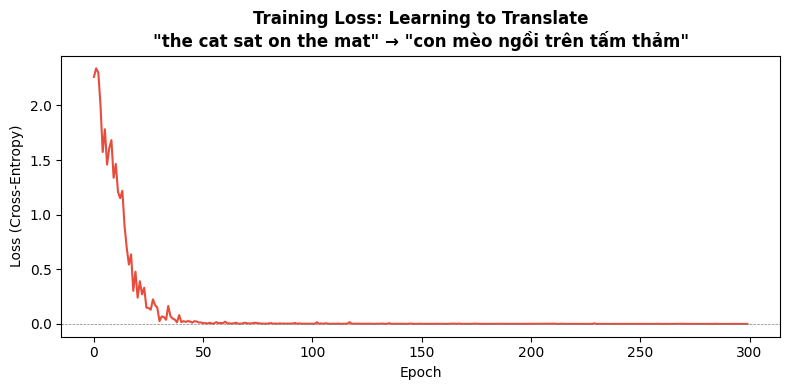

The loss starts high (random predictions) and decreases toward zero.
This model is overfitting on one sentence -- and that is the point!
It proves the Transformer architecture can learn the translation mapping.

In a real system, we would train on thousands of sentence pairs.


In [38]:
# 8e. Training loss curve

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, color='#e74c3c', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (Cross-Entropy)')
ax.set_title('Training Loss: Learning to Translate\n'
             '"the cat sat on the mat" \u2192 "con mèo ngồi trên tấm thảm"',
             fontweight='bold')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()

print('The loss starts high (random predictions) and decreases toward zero.')
print('This model is overfitting on one sentence -- and that is the point!')
print('It proves the Transformer architecture can learn the translation mapping.')
print()
print('In a real system, we would train on thousands of sentence pairs.')

---
## Thank you for listening!
